As we have extracted all articles from 1999-2025 that correspodnd to our query words and tags, we move forward by filtering the real accident reports from false positives (debates, safety campaigns). We will do this by computing a score function for every candidate article. We will build dictionaries containing key-phrases : ACCIDENT_DESCRIPTION, INJURIES_FATALITIES, VEHICLE_TERMS, EMERGENCY_RESPONSE, POLICY_INFRASTRUCTURE.Having these, we can count the number of matches from a candidate article with the ones from these dictionaries.

In [20]:
ACCIDENT_DESCRIPTION = [
    "traffic accident", "collision", "crash", "road accident",
    "pile-up", "multi-vehicle", "hit-and-run", "head-on",
    "rear-end", "side-impact", "rollover", "overturned",
    "car skidded", "lost control"
]

INJURIES_FATALITIES = [
    "injured", "seriously injured", "critically injured", "minor injuries",
    "fatalities", "killed", "pronounced dead", "died at the scene",
    "taken to hospital", "life-threatening", "non-life-threatening"
]

VEHICLE_TERMS = [
    "car", "vehicle", "motorcycle", "lorry", "truck", "bus",
    "van", "bicycle", "bike", "pedestrian", "cyclist", "driver", "passenger"
]

EMERGENCY_RESPONSE = [
    "police", "paramedics", "ambulance", "firefighters",
    "air ambulance", "emergency crews", "scene secured", "investigation launched"
]

POLICY_INFRASTRUCTURE = [
    "road safety campaign", "infrastructure", "policy", "legislation",
    "transport strategy", "road investment", "funding", 
    "highway improvements", "new traffic rules", "committee", "debate"
]


In [21]:
import re
import os
import json

# function that computes a score 
def compute_accident_score(text):
    
    text = text.lower()
    
    def count_matches(phrases):
        return sum(1 for p in phrases if p in text)
    
    score = 0
    
    score += 3 * count_matches(ACCIDENT_DESCRIPTION)
    score += 3 * count_matches(INJURIES_FATALITIES)
    score += 2 * count_matches(VEHICLE_TERMS)
    score += 2 * count_matches(EMERGENCY_RESPONSE)
    score -= 3 * count_matches(POLICY_INFRASTRUCTURE)
    
    return score


def is_accident_article(text, threshold=5):
    return compute_accident_score(text) >= threshold

def classify_article(article):
    title = article.get("webTitle","")
    article_body = article.get("fields",{}).get("bodyText","")
    
    combined = f"{title}\n{article_body}"
    score = compute_accident_score(combined)
    
    # return a dictionary
    return {
        "title": title,
        "body": article_body,
        "is_accident": score >= 25,
        "score": score 
    }
    
def classify_article_range(folder):
    
    results = []
    
    for filename in os.listdir(folder):
        if filename.endswith(".json"):
            full_path = os.path.join(folder, filename)
            
            with open(full_path, "r") as f:
                data = json.load(f)
                
            if isinstance(data,list):
                articles = data
            else:
                continue
            
            for art in articles:
                classified = classify_article(art)
                classified["file"] = filename
                results.append(classified)
            
        
    return results
        
        
    

In [22]:



BASE_DIR = "/Users/bocuradu/Documents/TMM/project/articles"
ARTICLES_1999_2009 = os.path.join(BASE_DIR,"1999-2009")
ARTICLES_2010_2019 = os.path.join(BASE_DIR,"2010-2019")
ARTICLES_2020_2025 = os.path.join(BASE_DIR,"2020-2025")

classification_1999_2009 = classify_article_range(ARTICLES_1999_2009)
classification_2010_2019 = classify_article_range(ARTICLES_2010_2019)
classification_2020_2025 = classify_article_range(ARTICLES_2020_2025)



In [23]:
def nr_accidents_range(folder):
    return sum(1 for p in folder if p["is_accident"] == True)

In [24]:
nr_accidents_1999_2009 = nr_accidents_range(classification_1999_2009) 
print(f"There are {nr_accidents_1999_2009}  out of {len(classification_1999_2009)} in range 1999-2009")
nr_accidents_2010_2019 = nr_accidents_range(classification_2010_2019) 
print(f"There are {nr_accidents_2010_2019}  out of {len(classification_2010_2019)} in range 2010-2019")
nr_accidents_2020_2025 = nr_accidents_range(classification_2020_2025) 
print(f"There are {nr_accidents_2020_2025}  out of {len(classification_2020_2025)} in range 2020-2025")

# articles that pass the threshold 
actual_car_crashes_1999_2009 = [d for d in classification_1999_2009 if d["is_accident"] == True]
actual_car_crashes_2010_2019 = [d for d in classification_2010_2019 if d["is_accident"] == True ]
actual_car_crashes_2020_2025 = [d for d in classification_2020_2025 if d["is_accident"] == True ]    
    
    

There are 64  out of 2705 in range 1999-2009
There are 71  out of 1464 in range 2010-2019
There are 18  out of 620 in range 2020-2025


Not, that we have managed to filter more the results, extracting the articles that indeed make reference to car accidents. We will define a series of lists containing most known cases that lead to accidents. These are : CAUSE_DRIVER, CAUSE_DISTRACTION, CAUSE_IMPAIRMENT, CAUSE_ENVIRONMENT, CAUSE_MECHANICAL, CAUSE_EMERGING.

In [25]:
# driver's fault
CAUSE_DRIVER = [
    "speeding", "speed too fast", "lost control", "fatigue",
    "fell asleep", "driver error", "dangerous driving",
    "reckless driving", "tailgating", "failed to stop",
    "failed to give way", "overtaking", "hit and run"
]

# distracted when driving
CAUSE_DISTRACTION = [
    "using mobile", "using phone", "texting", "distracted",
    "looking at", "not paying attention", "adjusting",
    "inattention"
]

# agents that contribute to the awareness of the driver
CAUSE_IMPAIRMENT = [
    "drunk", "drink driving", "alcohol", "drug driving",
    "under the influence", "cannabis", "cocaine", "intoxicated"
]

# environmental conditions
CAUSE_ENVIRONMENT = [
    "icy road", "black ice", "fog", "heavy rain",
    "slippery surface", "poor visibility", "snow", "high winds"
]

# vehicle failure 
CAUSE_MECHANICAL = [
    "brake failure", "tyre burst", "tire burst", "engine failure",
    "mechanical failure", "technical fault", "wheel came off"
]

# emerfing cases
CAUSE_EMERGING = [
    "battery fire", "ev fire", "autonomous system", "self-driving",
    "driver assist", "ai system", "lane assist failure",
    "electric vehicle fire"
]



In [26]:
# define a dictionary containing all causes
CAUSE_CATEGORIES = {
    "driver": CAUSE_DRIVER,
    "distraction": CAUSE_DISTRACTION,
    "impairment": CAUSE_IMPAIRMENT,
    "environment": CAUSE_ENVIRONMENT,
    "mechanical": CAUSE_MECHANICAL,
    "emerging": CAUSE_EMERGING
    
}

In [27]:
from collections import defaultdict

def extract_cause_phrases(text):
    
    text = text.lower()
    # split by sentences
    sentences = re.split(r"[.!?]", text)
    
    matches = []
    
    for sent in sentences:
        sent_clean = sent.strip()
        if not sent_clean:
            continue
        
        for category, phrases in CAUSE_CATEGORIES.items():
            for phrase in phrases:
                if phrase in sent_clean:
                    matches.append({
                        # dictionary that classifies every sentence within an artivlr
                        "category": category,
                        "phrase": phrase, # phrase that appears in the sentence
                        "sentence": sent_clean    # the sentence itself
                    })
    return matches

In [28]:
def extract_causes_from_collection(collection):
    all_matches = []
    
    for elem in collection: 
        
        #extracting the elements of a dictionary corresponding to an article
        title = elem["title"]
        content = elem["body"]
        filename = elem["file"]
        combined =title + "\n" + content
        
        matches = extract_cause_phrases(combined)
        for m in matches: 
            m["file"] = filename
            m["title"] = title
            all_matches.append(m)
    return all_matches
            
    
    
        
        
            
        
            
    

In [29]:
causes_1999_2009 = extract_causes_from_collection(actual_car_crashes_1999_2009)
causes_2010_2019 = extract_causes_from_collection(actual_car_crashes_2010_2019)
causes_2020_2025 = extract_causes_from_collection(actual_car_crashes_2020_2025)

In [30]:
import pandas as pd

#placing the json in a dataframe to be more readable
df_causes_1999_2009 = pd.DataFrame(causes_1999_2009)
df_causes_2010_2019 = pd.DataFrame(causes_2010_2019)
df_causes_2020_2025 = pd.DataFrame(causes_2020_2025)


df_causes_1999_2009.head(20)


,category,phrase,sentence,file,title
0,driver,tailgating,"that said, parisian drivers are, even when tem...",2001-08-25.json,War on the driver
1,distraction,looking at,"glasgow, durham, reading, poole, northamptonsh...",2001-08-25.json,War on the driver
2,driver,speeding,•around a million speeding tickets are issued ...,2001-08-25.json,War on the driver
3,environment,black ice,"robert harris, 47, was driving on the a547 nea...",2006-08-03.json,Driver fined £180 over crash that killed cyclists
4,environment,black ice,the examination has found there was no liquid ...,2006-08-03.json,Driver fined £180 over crash that killed cyclists
5,driver,fell asleep,"45pm london to king's lynn service derailed, s...",2003-07-07.json,Rail accidents chronology
6,distraction,inattention,casualties: 7 injured southall date: september...,2003-07-07.json,Rail accidents chronology
7,driver,speeding,mr naylor was caught speeding at 103mph on the...,2004-05-27.json,Speeders on the fast-track to court
8,driver,dangerous driving,"""if the speed and circumstances warrant it, we...",2004-05-27.json,Speeders on the fast-track to court
9,driver,dangerous driving,we believe that the government should now focu...,2009-12-15.json,Risky cycling rarely to blame for bike acciden...


In [31]:
df_causes_2010_2019.head(15)

,category,phrase,sentence,file,title
0,driver,overtaking,one of his experiments to research attitudes t...,2015-07-01.json,Sabotage and hatred: what have people got agai...
1,driver,speeding,people notice a cyclist pedalling through a re...,2015-07-01.json,Sabotage and hatred: what have people got agai...
2,driver,overtaking,"” in 2013, walker led a study that saw a co-re...",2015-07-01.json,Sabotage and hatred: what have people got agai...
3,distraction,adjusting,but rather than adjusting their driving to the...,2015-07-01.json,Sabotage and hatred: what have people got agai...
4,environment,snow,snow brings more chaos to uk\ncommuters were d...,2010-01-13.json,Snow brings more chaos to UK
5,environment,snow,some drivers caught on the a38 in exeter were ...,2010-01-13.json,Snow brings more chaos to UK
6,environment,snow,"higher ground in devon, particularly on dartmo...",2010-01-13.json,Snow brings more chaos to UK
7,environment,snow,"the snow eased in the early hours, to be repla...",2010-01-13.json,Snow brings more chaos to UK
8,environment,snow,the snow has led to some unusual sights,2010-01-13.json,Snow brings more chaos to UK
9,environment,snow,"""snow rolls"" ‑ large cylindrical formations of...",2010-01-13.json,Snow brings more chaos to UK


In [32]:
df_causes_2020_2025.head(15)

,category,phrase,sentence,file,title
0,driver,speeding,"mary williams, the chief executive of brake, s...",2022-10-09.json,Male drivers three times more likely to be in ...
1,distraction,looking at,cheaper models will set you back less than £10...,2022-04-27.json,‘I know they’re exciting – but calm down!’ Bri...
2,driver,lost control,an inquest concluded that hartridge had lost c...,2022-04-27.json,‘I know they’re exciting – but calm down!’ Bri...
3,environment,heavy rain,north-east scotland was badly affected by heav...,2020-08-12.json,Stonehaven train crash: three dead after derai...
4,driver,dangerous driving,the driver in the wimbledon crash was arrested...,2023-07-23.json,The Guardian view on road safety: recent death...
5,driver,dangerous driving,last year’s police and crime bill increased th...,2023-07-23.json,The Guardian view on road safety: recent death...
6,driver,dangerous driving,a new offence of causing injury by careless dr...,2023-07-23.json,The Guardian view on road safety: recent death...
7,environment,snow,the village of capel curig in snowdonia record...,2024-01-22.json,Storm Isha: two dead after separate road colli...
8,environment,high winds,the village of capel curig in snowdonia record...,2024-01-22.json,Storm Isha: two dead after separate road colli...
9,environment,high winds,he said other incidents attended by firefighte...,2024-01-22.json,Storm Isha: two dead after separate road colli...


In [33]:
df_causes_1999_2009["period"] = "1999-2009"
df_causes_2010_2019["period"] = "2010-2019"
df_causes_2020_2025["period"] = "2020-2025"

# we concact all dataframes 
df_all = pd.concat([df_causes_1999_2009, df_causes_2010_2019, df_causes_2020_2025])


In [34]:
category_counts = (df_all.groupby(["period", "category"]).size().reset_index(name="count"))
category_counts.head(30)

,period,category,count
0,1999-2009,distraction,5
1,1999-2009,driver,51
2,1999-2009,environment,23
3,1999-2009,impairment,6
4,2010-2019,distraction,18
5,2010-2019,driver,38
6,2010-2019,emerging,1
7,2010-2019,environment,363
8,2010-2019,impairment,13
9,2020-2025,distraction,1


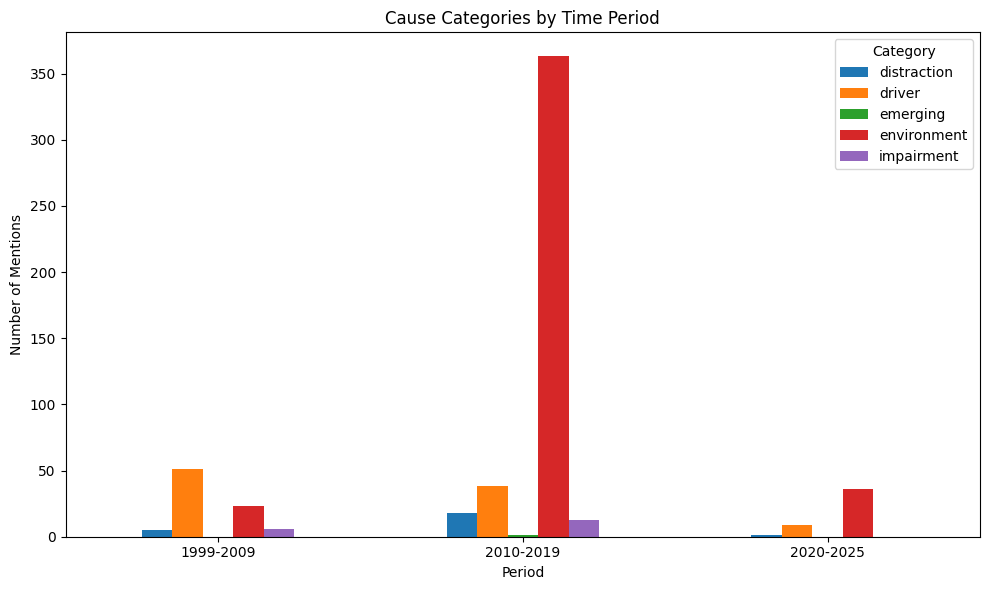

In [35]:
import matplotlib.pyplot as plt

pivot = category_counts.pivot(index="category", columns="period", values="count").fillna(0)

pivot.T.plot(kind="bar", figsize=(10,6))
plt.title("Cause Categories by Time Period")
plt.ylabel("Number of Mentions")
plt.xlabel("Period")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.tight_layout()
plt.show()


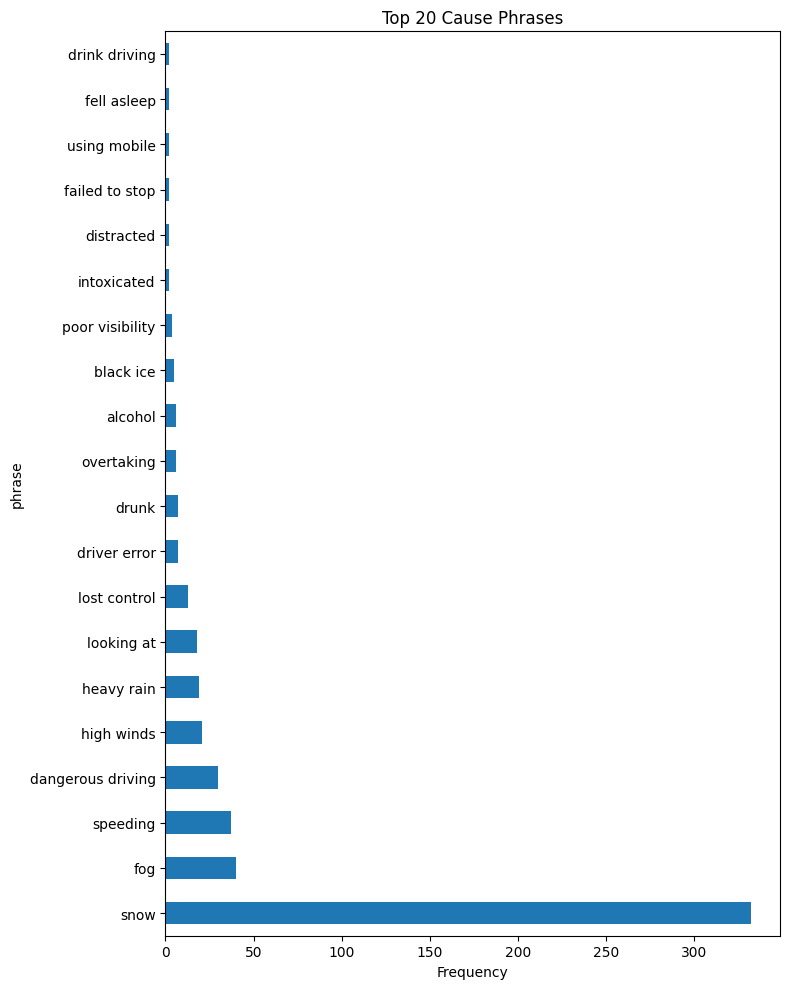

In [36]:
top_phrases = df_all["phrase"].value_counts().head(20)

top_phrases.plot(kind="barh", figsize=(8,10))
plt.title("Top 20 Cause Phrases")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()


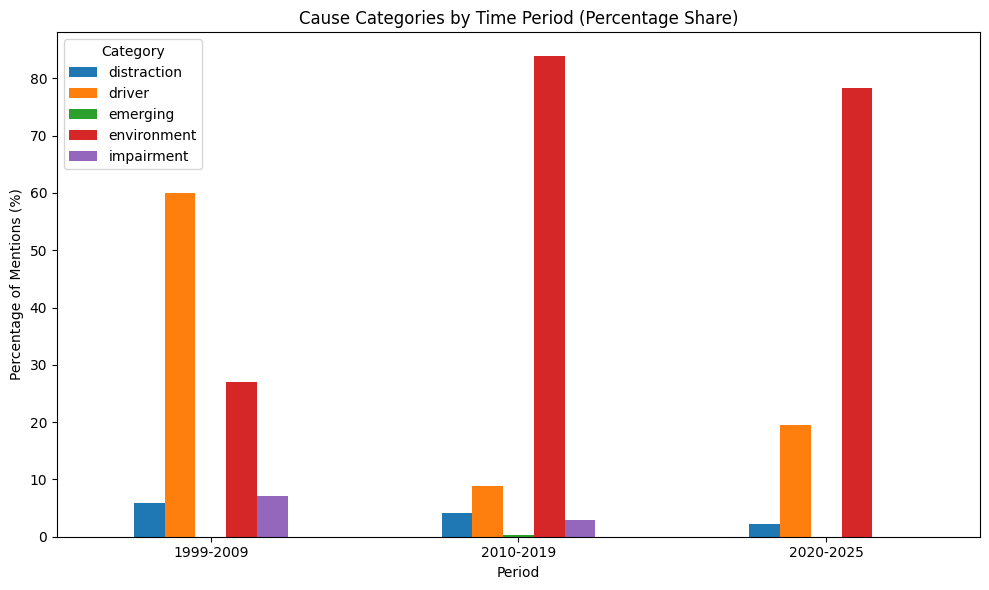

In [37]:
pivot_pct = pivot.divide(pivot.sum(axis=0), axis=1) * 100

# Plot
pivot_pct.T.plot(kind="bar", figsize=(10,6))
plt.title("Cause Categories by Time Period (Percentage Share)")
plt.ylabel("Percentage of Mentions (%)")
plt.xlabel("Period")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

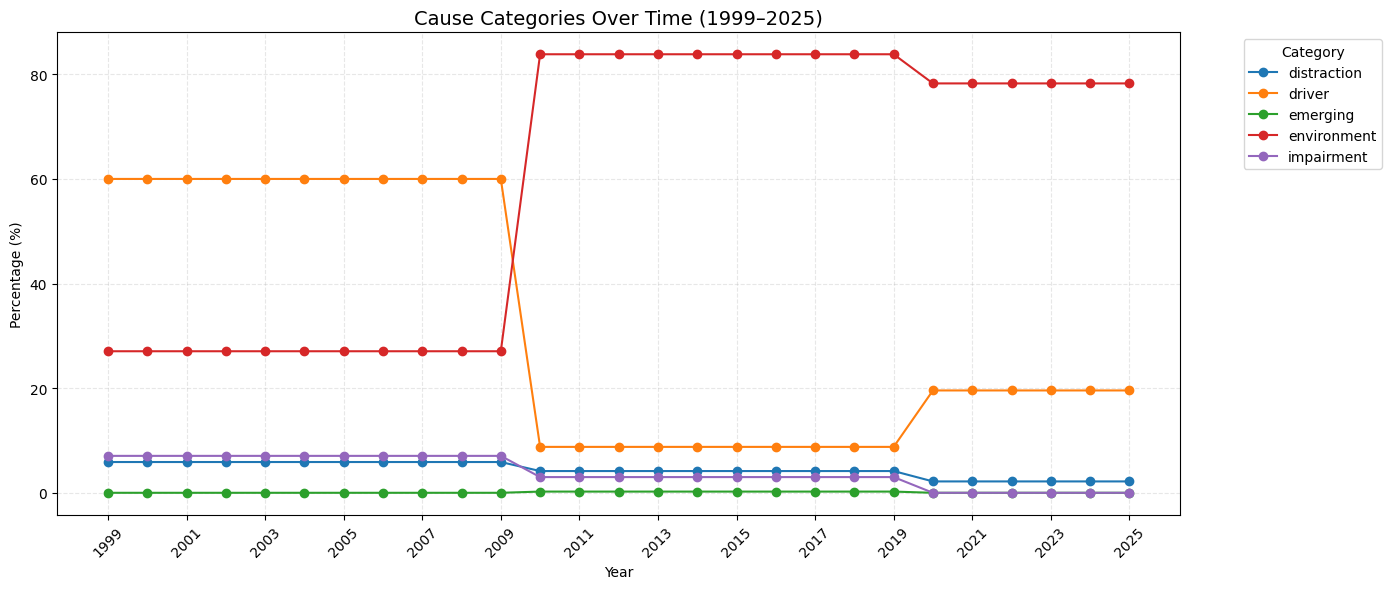

In [38]:

df = category_counts.copy()
df["total"] = df.groupby("period")["count"].transform("sum")
df["percentage"] = (df["count"] / df["total"]) * 100
period_years = {
    "1999-2009": list(range(1999, 2010)),
    "2010-2019": list(range(2010, 2020)),
    "2020-2025": list(range(2020, 2026)),
}
rows = []
for _, row in df.iterrows():
    period = row["period"]
    category = row["category"]
    pct = row["percentage"]

    for year in period_years[period]:
        rows.append({
            "year": year,
            "category": category,
            "percentage": pct
        })

df_yearly = pd.DataFrame(rows)
pivot_yearly = df_yearly.pivot(index="year", columns="category", values="percentage").fillna(0)
plt.figure(figsize=(14, 6))

for category in pivot_yearly.columns:
    plt.plot(pivot_yearly.index, pivot_yearly[category], marker="o", label=category)

plt.title("Cause Categories Over Time (1999–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(range(1999, 2026, 2), rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()
